# Figures for Slides
### SIAM Life Sciences 2026 — Deep Learning Section

This notebook generates publication-quality figures for use in slides.
Run each section independently to produce and save individual figures.

**Contents:**
1. Activation functions: ReLU and Sigmoid
2. *(Add more figures here as needed)*

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Global style ─────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family'      : 'sans-serif',
    'font.sans-serif'  : ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'        : 16,
    'axes.titlesize'   : 20,
    'axes.labelsize'   : 18,
    'xtick.labelsize'  : 14,
    'ytick.labelsize'  : 14,
    'legend.fontsize'  : 15,
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 1.4,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
    'grid.alpha'       : 0.35,
    'grid.linestyle'   : '--',
    'grid.linewidth'   : 0.8,
})

print('Style loaded.')

Style loaded.


---
## 1. Activation Functions: ReLU and Sigmoid

$$\text{ReLU}(x) = \max(0, x) \qquad \sigma(x) = \frac{1}{1 + e^{-x}}$$

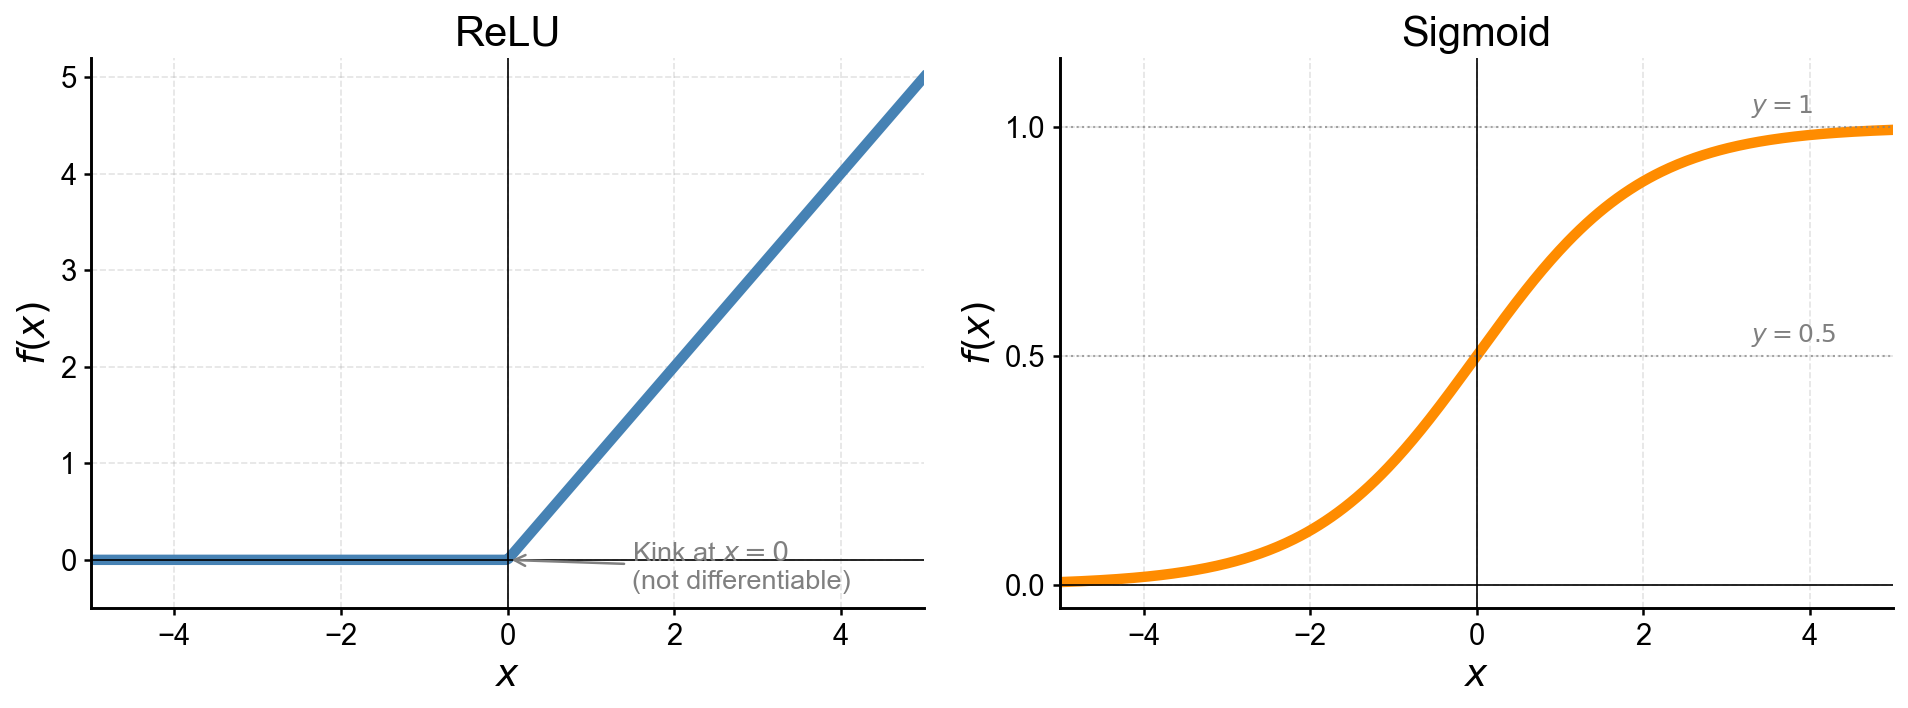

Saved: activation_functions.png


In [7]:
x = np.linspace(-5, 5, 400)
relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ReLU ─────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, relu, color='steelblue', lw=5)
ax.axhline(0, color='black', lw=0.8, ls='-')
ax.axvline(0, color='black', lw=0.8, ls='-')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('ReLU')
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5.2)
ax.grid(True)
# Annotate the kink
ax.annotate('Kink at $x=0$\n(not differentiable)',
            xy=(0, 0), xytext=(1.5, -0.3),
            fontsize=13, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# ── Sigmoid ───────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x, sigmoid, color='darkorange', lw=5)
ax.axhline(0,   color='black', lw=0.8, ls='-')
ax.axhline(1,   color='gray',  lw=1.0, ls=':', alpha=0.7)
ax.axhline(0.5, color='gray',  lw=1.0, ls=':', alpha=0.7)
ax.axvline(0,   color='black', lw=0.8, ls='-')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Sigmoid')
ax.set_xlim(-5, 5)
ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 0.5, 1.0])
ax.grid(True)
# Annotate asymptotes
ax.text(3.3, 1.03, '$y = 1$', fontsize=12, color='gray')
ax.text(3.3, 0.53, '$y = 0.5$', fontsize=12, color='gray')

#plt.suptitle('Activation Functions', fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: activation_functions.png')

In [ ]:
# ── Individual ReLU figure (for slides where you show one at a time) ──────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, relu, color='steelblue', lw=3.5)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('$x$', fontsize=20)
ax.set_ylabel('$\\mathrm{ReLU}(x)$', fontsize=20)
ax.set_title('$\\mathrm{ReLU}(x) = \\max(0,\, x)$', fontsize=22, pad=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 5.2)
ax.grid(True)
plt.tight_layout()
plt.savefig('relu.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: relu.png')

In [ ]:
# ── Individual Sigmoid figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, sigmoid, color='darkorange', lw=3.5)
ax.axhline(0,   color='black', lw=0.8)
ax.axhline(1,   color='gray',  lw=1.0, ls=':', alpha=0.8)
ax.axhline(0.5, color='gray',  lw=1.0, ls=':', alpha=0.8)
ax.axvline(0,   color='black', lw=0.8)
ax.set_xlabel('$x$', fontsize=20)
ax.set_ylabel('$\\sigma(x)$', fontsize=20)
ax.set_title(r'$\sigma(x) = \dfrac{1}{1+e^{-x}}$', fontsize=22, pad=12)
ax.set_xlim(-5, 5)
ax.set_ylim(-0.05, 1.15)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.text(3.4, 1.03,  '$y = 1$',   fontsize=13, color='gray')
ax.text(3.4, 0.435, '$y = 0.5$', fontsize=13, color='gray')
ax.grid(True)
plt.tight_layout()
plt.savefig('sigmoid.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: sigmoid.png')

---
## 2. Two Inputs, One Output: Sigmoid as a Surface

With inputs $x_1, x_2 \in \mathbb{R}$ and a single neuron:

$$a = \sigma(w_1 x_1 + w_2 x_2 + b), \qquad a \in [0, 1]$$

The pre-activation $z = w_1 x_1 + w_2 x_2 + b$ is a tilted plane.  
Sigmoid squashes it into a smooth ramp from 0 to 1.  
The **decision boundary** (where $a = 0.5$) is the line $w_1 x_1 + w_2 x_2 + b = 0$.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# ── Parameters — try changing these to see the effect ────────────────────────
w1 = 1.5    # weight on x1  (rotates boundary)
w2 = 1.0    # weight on x2  (rotates boundary)
b  = -1.0   # bias           (shifts boundary)

# ── Grid ─────────────────────────────────────────────────────────────────────
x1 = np.linspace(-4, 4, 200)
x2 = np.linspace(-4, 4, 200)
X1, X2 = np.meshgrid(x1, x2)

Z = w1*X1 + w2*X2 + b          # pre-activation (tilted plane)
A = 1 / (1 + np.exp(-Z))       # sigmoid output (smooth ramp)

# Decision boundary: w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b)/w2
x1_db = np.linspace(-4, 4, 100)
x2_db = -(w1*x1_db + b) / w2

fig = plt.figure(figsize=(14, 5))

# ── 3D surface ────────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax3d.plot_surface(X1, X2, A, cmap='coolwarm', alpha=0.85,
                         linewidth=0, antialiased=True)
ax3d.set_xlabel('$x_1$', fontsize=14, labelpad=8)
ax3d.set_ylabel('$x_2$', fontsize=14, labelpad=8)
ax3d.set_zlabel('$a = \sigma(z)$', fontsize=14, labelpad=8)
ax3d.set_title(f'Sigmoid surface\n$w_1={w1},\; w_2={w2},\; b={b}$', fontsize=15)
ax3d.set_zlim(0, 1)
fig.colorbar(surf, ax=ax3d, shrink=0.5, pad=0.1)

# ── 2D heatmap + decision boundary ───────────────────────────────────────────
ax2d = fig.add_subplot(1, 2, 2)
hm = ax2d.contourf(X1, X2, A, levels=50, cmap='coolwarm', vmin=0, vmax=1)
fig.colorbar(hm, ax=ax2d, label='$a = \sigma(z)$')

# Decision boundary
ax2d.plot(x1_db, x2_db, 'k-', lw=2.5, label='Decision boundary ($a = 0.5$)')
ax2d.set_xlim(-4, 4); ax2d.set_ylim(-4, 4)
ax2d.set_xlabel('$x_1$', fontsize=16)
ax2d.set_ylabel('$x_2$', fontsize=16)
ax2d.set_title('Output heatmap + decision boundary', fontsize=15)
ax2d.legend(fontsize=12, loc='upper right')

# Annotate regions
ax2d.text(-3, 3,  '$a \\approx 1$', fontsize=13, color='white', fontweight='bold')
ax2d.text( 1.5, -3, '$a \\approx 0$', fontsize=13, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('sigmoid_2d_surface.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Decision boundary: {w1}*x1 + {w2}*x2 + {b} = 0')
print('Saved: sigmoid_2d_surface.png')